In [1]:
%load_ext autoreload
%autoreload 2
import sys
from scipy.fftpack import dctn, idctn
from csbdeep.utils import normalize
import pywt

sys.path.append("..")
from src import *

Cupy Available= 1


# Video Fusion With Discrete Fourier Transform (DFT)
Can we augment a denoiser output using a sliding window on the raw footage and DFT video fusion?

This can be used to **reduce the number of training steps for deep-learning models**, which are known to be expensive to train. This is the case with DeepCAD-RT, which uses a 3D UNet.

In [2]:
patch_t = 600
patch_xy = 256
avg_win = 2048
shape_p = (patch_t, patch_xy, patch_xy)

In [17]:
meta = DATASETS["synthetic"]
y_path = DATASETS["synthetic"].dir / "deepcad_E_10.tif"
x, y, gt = (Recording(_, max_frames=2048) for _ in [meta.x, meta.dir / "deepcad_15.tiff", meta.gt])
RES_DIR = mkdir("results/synthetic/")

In [18]:
x_p = x.np[:patch_t, :patch_xy, :patch_xy]
y_hat_p = y.np[:patch_t, :patch_xy, :patch_xy]
gt_p = gt.np[:patch_t, :patch_xy, :patch_xy]
y_bar_p = x.avg_fast(avg_win)[:patch_t, :patch_xy, :patch_xy]

In [19]:
def norm(arr):
    return np.clip(normalize(arr, 0.25, 99.5), 0, 1)


def fuse_wavelet(y_bar, y_hat, wavelet="db2"):
    Y_bar = pywt.dwtn(y_bar, wavelet=wavelet, axes=(0, 1, 2))
    Y_hat = pywt.dwtn(y_hat, wavelet=wavelet, axes=(0, 1, 2))

    Y = {}
    for key in Y_bar:
        if key == "aaa":
            Y[key] = Y_bar[key]
        else:
            Y[key] = Y_hat[key]

    return pywt.idwtn(Y, wavelet=wavelet, axes=(0, 1, 2))

In [37]:
wavelet = "db2" # "haar"

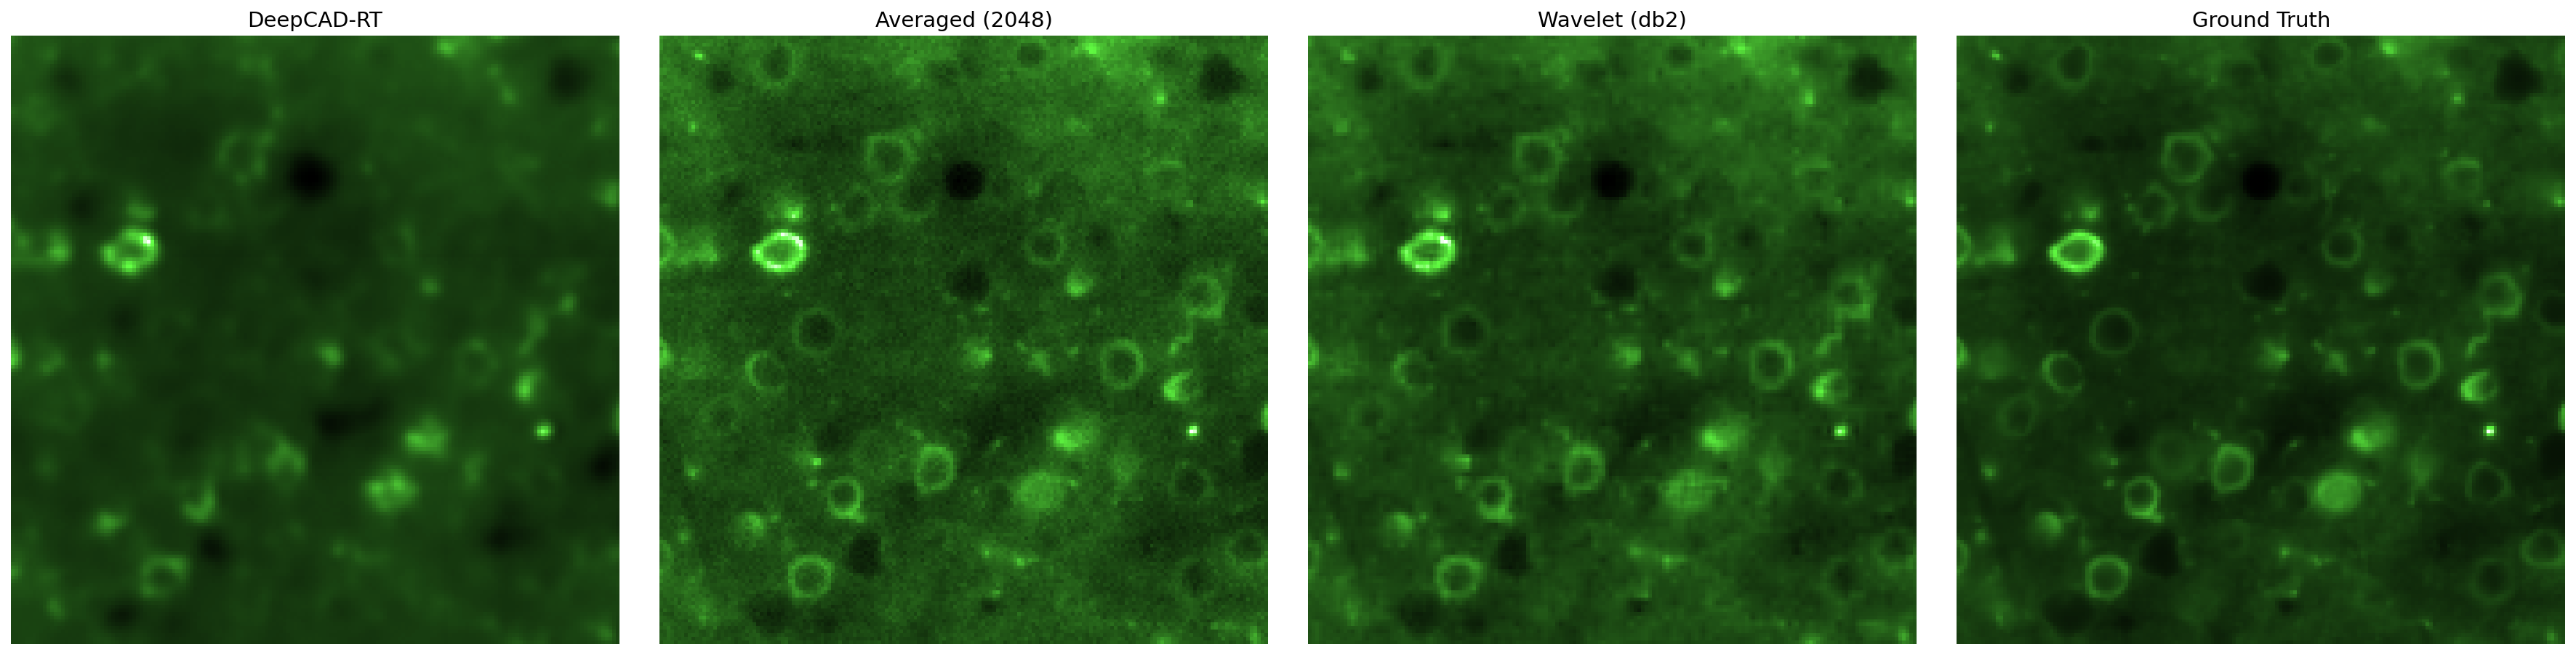

In [38]:
fused = fuse_wavelet(y_bar_p, y_hat_p, wavelet=wavelet)
i=100
imshow({
    "DeepCAD-RT":y_hat_p[i],
    f"Averaged ({avg_win})":y_bar_p[i],
    f"Wavelet ({wavelet})":fused[i],
    "Ground Truth":gt_p[i],
}, size=6, zoom=1.5)

## $PSNR_{3D}$ and $SSIM_{3D}$ Metrics

In [21]:
psnr3d(norm(y_hat_p), norm(gt_p)), ssim3d(norm(y_hat_p), norm(gt_p))

(np.float64(23.412859427210456), 0.6765005588531494)

In [39]:
psnr3d(norm(fused), norm(gt_p)), ssim3d(norm(fused), norm(gt_p))

(np.float64(21.54919199213351), 0.811968207359314)

## Temporal analysis

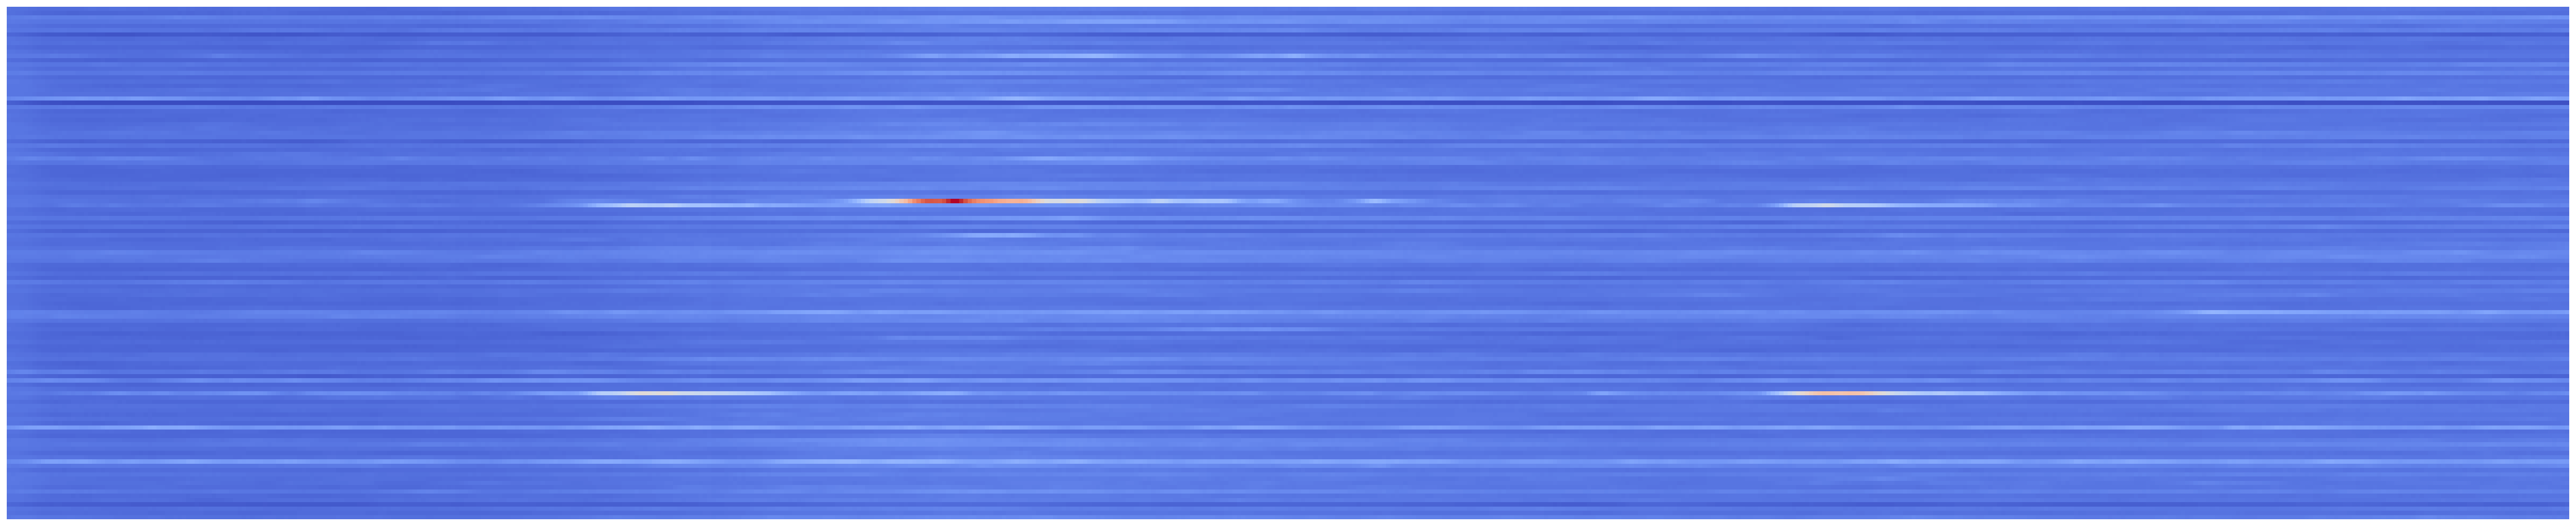

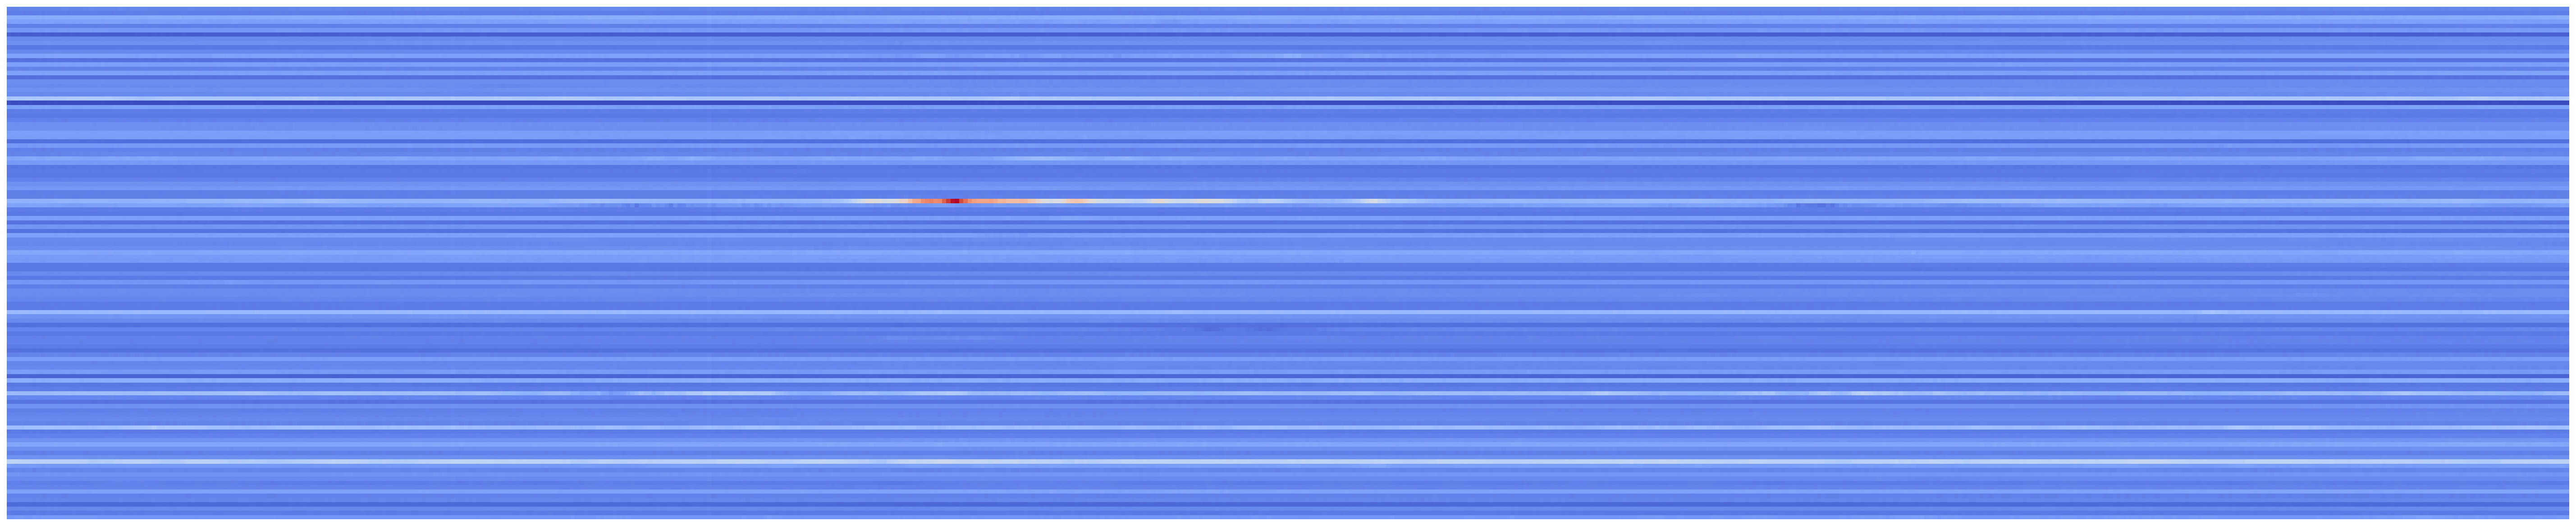

In [42]:
ROIS=120
rois_x = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))
rois_y = tuple(random.randrange(0, patch_xy) for _ in range(ROIS))

imshow(y_hat_p[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(y_bar_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")
imshow(fused[::1,rois_x, rois_y].T, size=40, cmap="coolwarm")
# imshow(gt_p[::2,rois_x, rois_y].T, size=40, cmap="coolwarm")